C:\Users\Asus TUF -PC\AppData\Local\Temp\ipykernel_14116\1036180507.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("mobilenetv3_best_w

Evaluating model on validation set...
Evaluating model on test set...
Finding optimal thresholds using validation data...
Computing per-class metrics with optimal thresholds...

---- Overall Model Performance ----
Best Validation Accuracy: 0.8016
Final Test Accuracy: 0.7890
Macro-averaged F1-score: 0.7845
Macro Precision: 0.8039
Macro Recall: 0.7885
Weighted AUC Score: 0.9666

---- Recommended Global Thresholds ----
Global F1 Threshold: 0.4800
Global Precision Threshold: 0.9380
Global Recall Threshold: 0.0100
Global Accuracy Threshold: 0.5800

---- Per-Class Performance (F1-optimized thresholds) ----
                     Class  Standard Accuracy  Thresholded Accuracy  \
3            CocosNucifera           0.986226              0.986368   
5         ElaeisGuineensis           0.973019              0.977137   
7         ManihotEsculenta           0.976001              0.971741   
9           TheobromaCacao           0.958393              0.961375   
1   BroussonetiaPapyrifera           

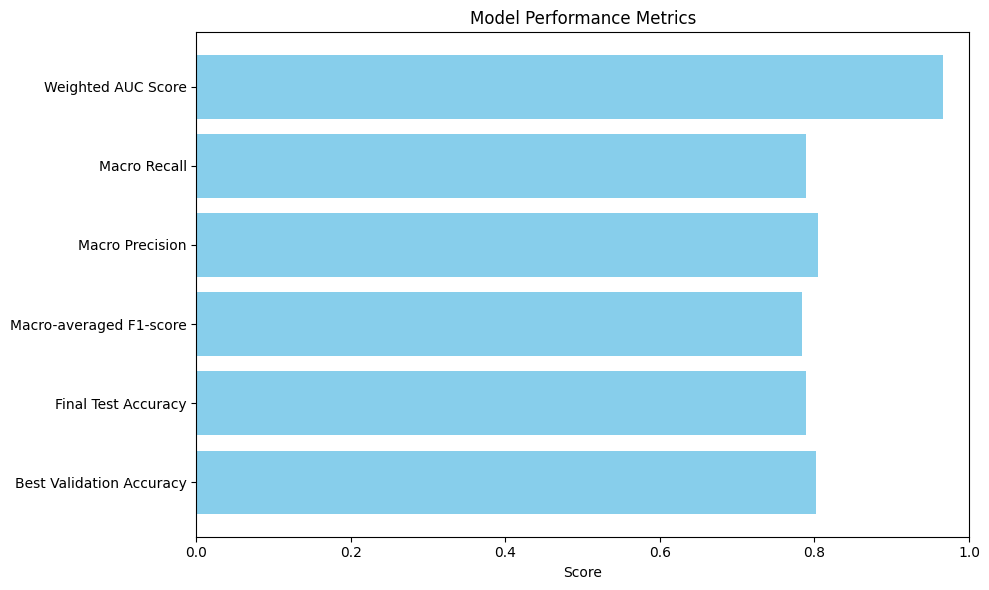

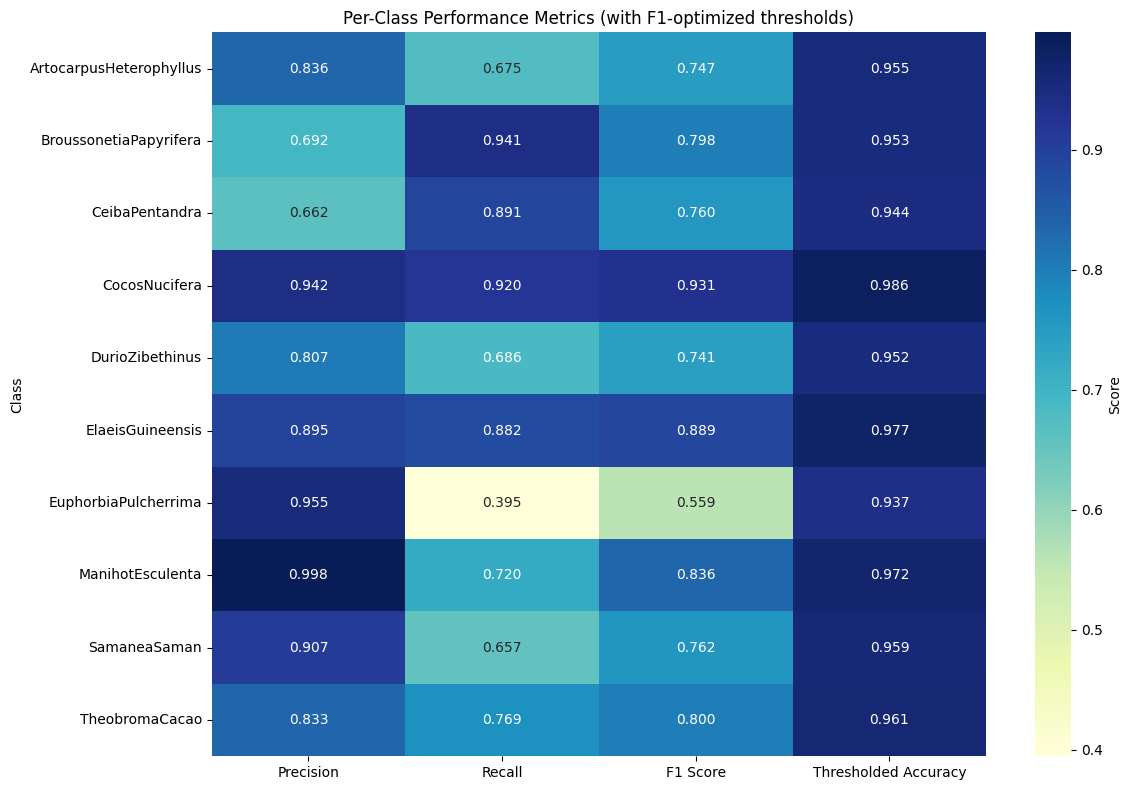

<Figure size 1200x600 with 0 Axes>

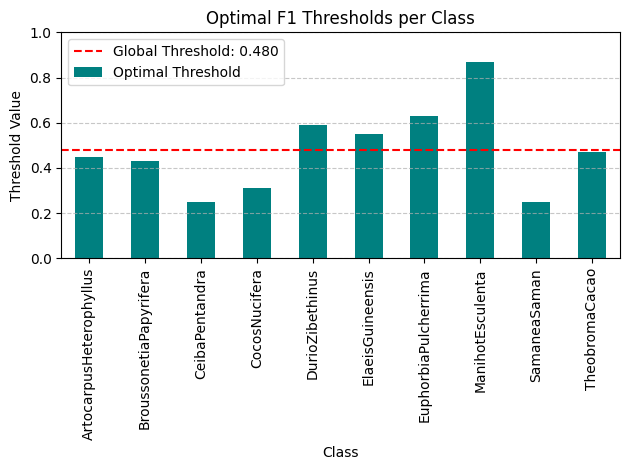

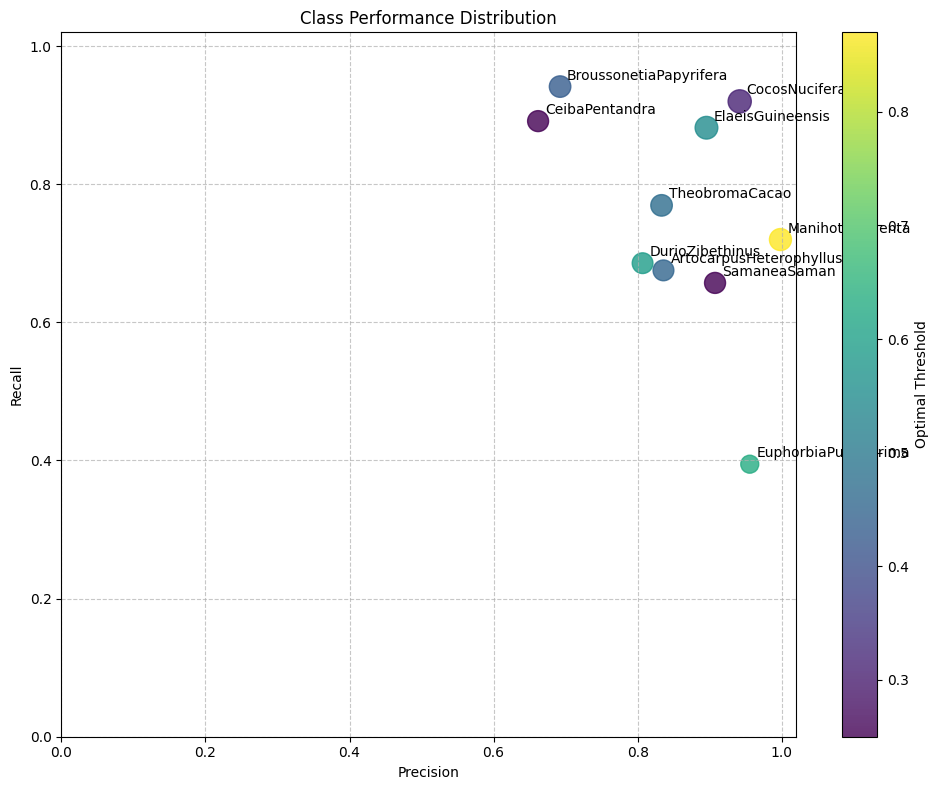

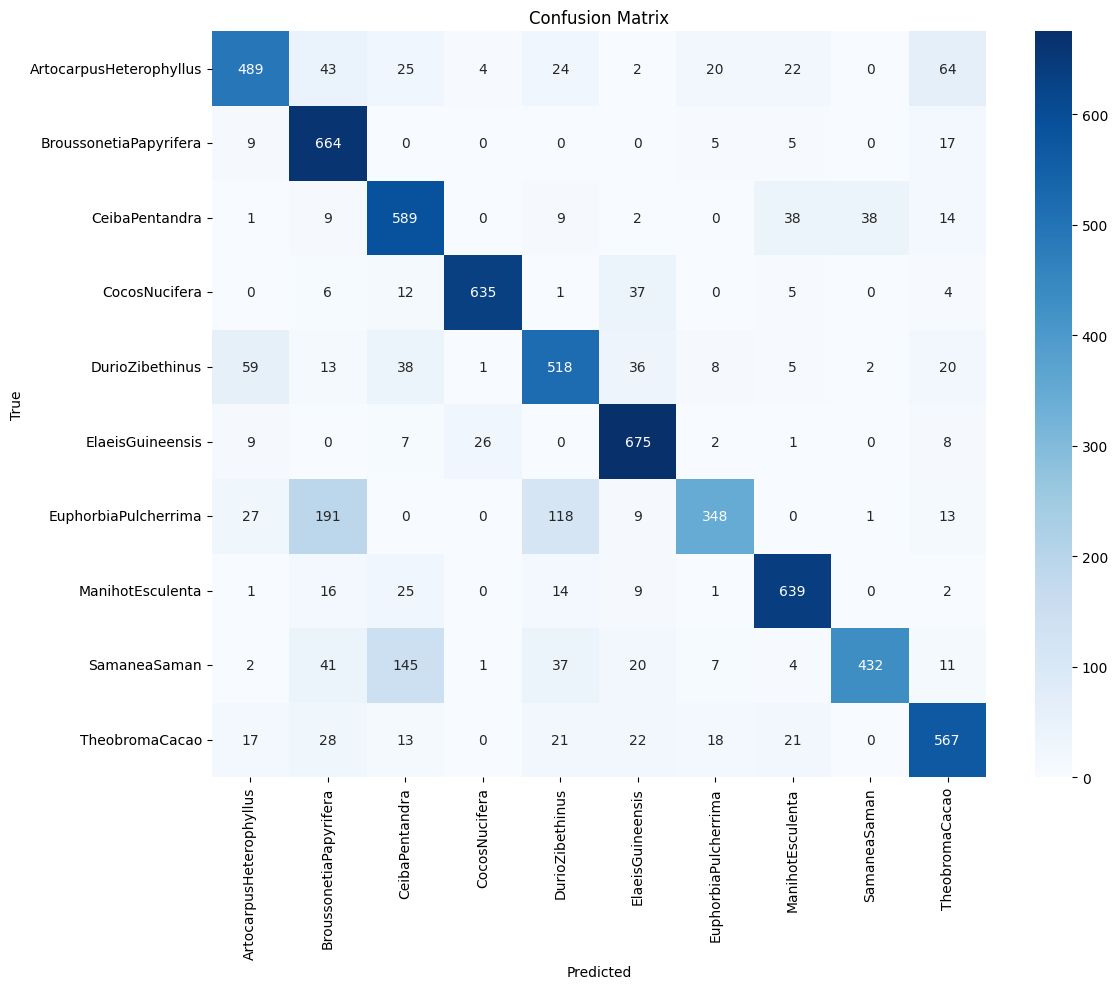


---- Class Acceptability Analysis ----
                     Class  F1 Score  Precision    Recall  \
3            CocosNucifera  0.930636   0.941520  0.920000   
5         ElaeisGuineensis  0.888581   0.895397  0.881868   
7         ManihotEsculenta  0.836483   0.998039  0.719943   
9           TheobromaCacao  0.800000   0.833078  0.769448   
1   BroussonetiaPapyrifera  0.797821   0.692227  0.941429   
2           CeibaPentandra  0.759586   0.661718  0.891429   
8             SamaneaSaman  0.762220   0.907298  0.657143   
0  ArtocarpusHeterophyllus  0.747007   0.835714  0.675325   
4          DurioZibethinus  0.741313   0.806723  0.685714   
6     EuphorbiaPulcherrima  0.558559   0.955479  0.394625   

   Thresholded Accuracy  Optimal Threshold  Acceptability Score Overall Rating  
3              0.986368               0.31                    4      Excellent  
5              0.977137               0.55                    4      Excellent  
7              0.971741               0.87   

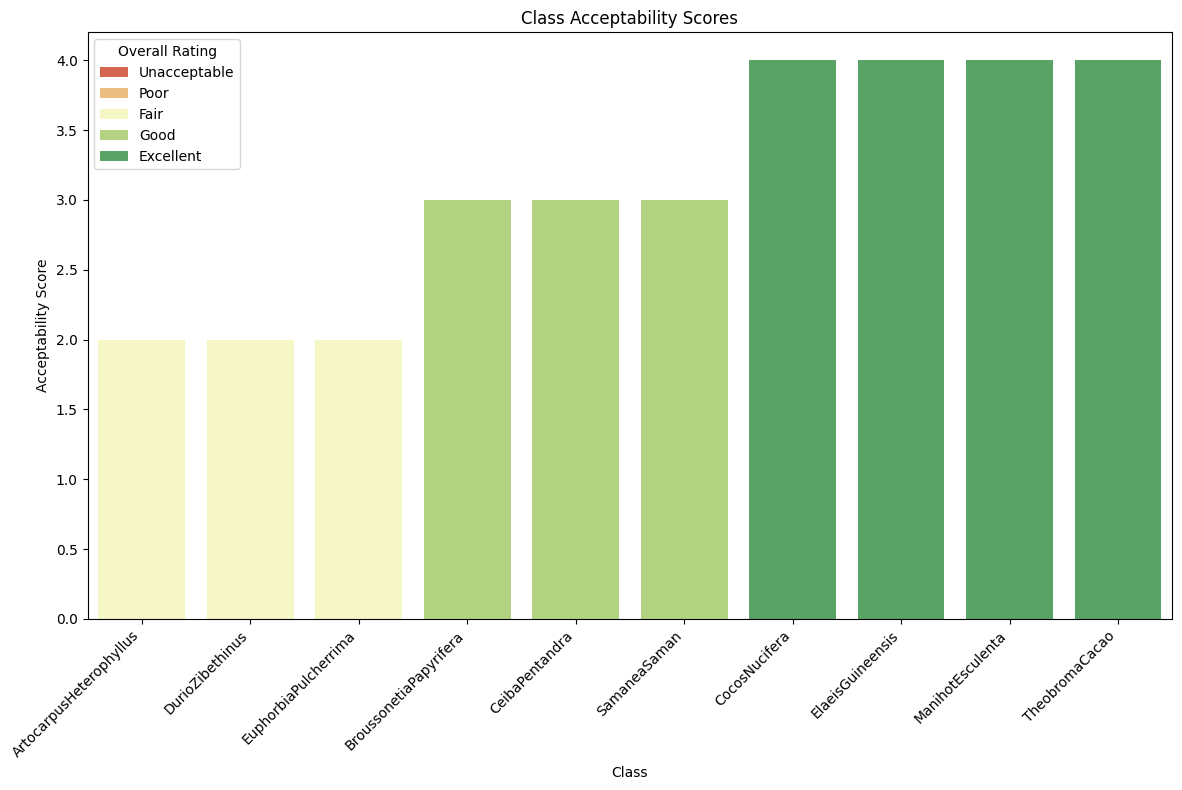


Analysis complete. Results and visualizations have been saved.


In [4]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import pandas as pd
import seaborn as sns

from model_architecture import LeafClassifier  # Replace with your model architecture file

# ------------------- Device Setup -------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------- CustomDataset Definition -------------------
class CustomDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.class_to_idx = {}
        self.idx_to_class = {}
        
        # Walk through directories
        for idx, class_name in enumerate(sorted(os.listdir(root_dir))):
            class_path = os.path.join(root_dir, class_name)
            if os.path.isdir(class_path):
                self.class_to_idx[class_name] = idx
                self.idx_to_class[idx] = class_name
                for img_name in os.listdir(class_path):
                    if img_name.lower().endswith((".png", ".jpg", ".jpeg")):
                        self.image_paths.append(os.path.join(class_path, img_name))
                        self.labels.append(idx)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)
        
        return image, label

# ------------------- Transformations -------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ------------------- Datasets and Dataloaders -------------------
test_dataset = CustomDataset(root_dir='LeafSenseProcessed/test', transform=transform)
val_dataset = CustomDataset(root_dir='LeafSenseProcessed/val', transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# ------------------- Load Model -------------------
num_classes = len(test_dataset.class_to_idx)
model = LeafClassifier(num_classes=num_classes, DROPOUT_RATE=0.25)
model.load_state_dict(torch.load("mobilenetv3_best_weights7.pth", map_location=device))
model.to(device)
model.eval()

# ------------------- Evaluation Function -------------------
def evaluate_model(loader):
    model.eval()
    all_labels = []
    all_preds = []
    all_outputs = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probabilities = torch.softmax(outputs, dim=1)

            all_labels.append(labels.cpu().numpy())
            all_preds.append(probabilities.cpu().numpy())
            all_outputs.append(outputs.cpu().numpy())

    all_labels = np.concatenate(all_labels)
    all_preds = np.concatenate(all_preds)
    all_outputs = np.concatenate(all_outputs)
    
    return all_labels, all_preds, all_outputs

# ------------------- Threshold Analysis Functions -------------------
def find_optimal_threshold(y_true, y_pred_proba, metric_name='f1'):
    """
    Find the optimal threshold value for each class that maximizes the specified metric
    
    Args:
        y_true: Binary ground truth labels (one-hot encoded)
        y_pred_proba: Predicted probabilities for each class
        metric_name: Metric to optimize ('f1', 'precision', 'recall')
        
    Returns:
        Dictionary of optimal thresholds for each class
    """
    thresholds = np.linspace(0.01, 0.99, 50)  # Test 50 threshold values
    optimal_thresholds = {}
    
    # For each class
    for class_idx in range(y_true.shape[1]):
        best_score = 0
        best_threshold = 0.5  # Default
        
        # Get true labels and predicted probabilities for this class
        class_true = y_true[:, class_idx]
        class_probs = y_pred_proba[:, class_idx]
        
        # Try different thresholds
        for threshold in thresholds:
            # Apply threshold
            class_preds = (class_probs >= threshold).astype(int)
            
            # Calculate metric
            if metric_name == 'f1':
                score = f1_score(class_true, class_preds, zero_division=0)
            elif metric_name == 'precision':
                score = precision_score(class_true, class_preds, zero_division=0)
            elif metric_name == 'recall':
                score = recall_score(class_true, class_preds, zero_division=0)
            elif metric_name == 'accuracy':
                score = np.mean(class_true == class_preds)
            
            # Update if better
            if score > best_score:
                best_score = score
                best_threshold = threshold
                
        optimal_thresholds[class_idx] = {
            'threshold': best_threshold,
            f'best_{metric_name}': best_score
        }
    
    return optimal_thresholds

def compute_class_metrics_with_threshold(labels, predictions, thresholds, idx_to_class):
    """
    Compute per-class metrics using optimal thresholds
    
    Args:
        labels: Ground truth labels
        predictions: Model predictions (probabilities)
        thresholds: Dictionary of optimal thresholds for each class
        idx_to_class: Dictionary mapping class indices to class names
        
    Returns:
        DataFrame with per-class metrics
    """
    class_metrics = []
    
    # Convert labels to one-hot
    n_classes = len(idx_to_class)
    labels_one_hot = label_binarize(labels, classes=range(n_classes))
    
    # Calculate standard metrics
    y_pred = predictions.argmax(axis=1)
    
    # For each class
    for class_idx in range(n_classes):
        class_name = idx_to_class[class_idx]
        
        # Apply threshold for this class
        class_threshold = thresholds[class_idx]['threshold']
        class_predictions = (predictions[:, class_idx] >= class_threshold).astype(int)
        
        # Calculate metrics
        true_class = (labels == class_idx)
        precision = precision_score(true_class, class_predictions, zero_division=0)
        recall = recall_score(true_class, class_predictions, zero_division=0)
        f1 = f1_score(true_class, class_predictions, zero_division=0)
        
        # Calculate accuracy for this class
        standard_preds = (y_pred == class_idx)
        thresholded_preds = class_predictions
        standard_accuracy = np.mean(standard_preds == true_class)
        thresholded_accuracy = np.mean(thresholded_preds == true_class)
        
        # Get mean prediction probability for this class's samples
        mean_prob = np.mean(predictions[true_class, class_idx])
        
        class_metrics.append({
            'Class': class_name,
            'Standard Accuracy': standard_accuracy,
            'Thresholded Accuracy': thresholded_accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1 Score': f1,
            'Optimal Threshold': class_threshold,
            'Mean Probability': mean_prob
        })
    
    return pd.DataFrame(class_metrics)

# ------------------- Evaluation Metrics -------------------
print("Evaluating model on validation set...")
val_labels, val_preds, val_outputs = evaluate_model(val_loader)
best_val_accuracy = np.mean(val_preds.argmax(axis=1) == val_labels)

print("Evaluating model on test set...")
test_labels, test_preds, test_outputs = evaluate_model(test_loader)
test_accuracy = np.mean(test_preds.argmax(axis=1) == test_labels)

# Calculate standard metrics
macro_f1 = f1_score(test_labels, test_preds.argmax(axis=1), average='macro')
macro_precision = precision_score(test_labels, test_preds.argmax(axis=1), average='macro')
macro_recall = recall_score(test_labels, test_preds.argmax(axis=1), average='macro')

# AUC requires label binarization
test_labels_bin = label_binarize(test_labels, classes=np.unique(test_labels))
weighted_auc = roc_auc_score(test_labels_bin, test_preds, average='weighted', multi_class='ovr')

# ------------------- Find Optimal Thresholds using Validation Set -------------------
print("Finding optimal thresholds using validation data...")
val_labels_bin = label_binarize(val_labels, classes=range(num_classes))

# Find optimal thresholds for different metrics
f1_thresholds = find_optimal_threshold(val_labels_bin, val_preds, 'f1')
precision_thresholds = find_optimal_threshold(val_labels_bin, val_preds, 'precision')
recall_thresholds = find_optimal_threshold(val_labels_bin, val_preds, 'recall')
accuracy_thresholds = find_optimal_threshold(val_labels_bin, val_preds, 'accuracy')

# ------------------- Apply Thresholds and Compute Per-Class Metrics -------------------
print("Computing per-class metrics with optimal thresholds...")
class_metrics_f1 = compute_class_metrics_with_threshold(
    test_labels, test_preds, f1_thresholds, test_dataset.idx_to_class
)
class_metrics_precision = compute_class_metrics_with_threshold(
    test_labels, test_preds, precision_thresholds, test_dataset.idx_to_class
)
class_metrics_recall = compute_class_metrics_with_threshold(
    test_labels, test_preds, recall_thresholds, test_dataset.idx_to_class
)
class_metrics_accuracy = compute_class_metrics_with_threshold(
    test_labels, test_preds, accuracy_thresholds, test_dataset.idx_to_class
)

# ------------------- Display Results -------------------
print("\n---- Overall Model Performance ----")
metrics = {
    'Best Validation Accuracy': best_val_accuracy,
    'Final Test Accuracy': test_accuracy,
    'Macro-averaged F1-score': macro_f1,
    'Macro Precision': macro_precision,
    'Macro Recall': macro_recall,
    'Weighted AUC Score': weighted_auc
}

for metric_name, value in metrics.items():
    print(f"{metric_name}: {value:.4f}")

# Recommended global thresholds (average of optimal thresholds)
avg_f1_threshold = np.mean([f1_thresholds[i]['threshold'] for i in f1_thresholds])
avg_precision_threshold = np.mean([precision_thresholds[i]['threshold'] for i in precision_thresholds])
avg_recall_threshold = np.mean([recall_thresholds[i]['threshold'] for i in recall_thresholds])
avg_accuracy_threshold = np.mean([accuracy_thresholds[i]['threshold'] for i in accuracy_thresholds])

print("\n---- Recommended Global Thresholds ----")
print(f"Global F1 Threshold: {avg_f1_threshold:.4f}")
print(f"Global Precision Threshold: {avg_precision_threshold:.4f}")
print(f"Global Recall Threshold: {avg_recall_threshold:.4f}")
print(f"Global Accuracy Threshold: {avg_accuracy_threshold:.4f}")

# Display per-class metrics with optimal F1 thresholds
print("\n---- Per-Class Performance (F1-optimized thresholds) ----")
print(class_metrics_f1.sort_values('F1 Score', ascending=False))

# ------------------- Visualizations -------------------
# 1. Overall Metrics
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(list(metrics.keys()), list(metrics.values()), color='skyblue')
ax.set_xlim(0, 1)
ax.set_xlabel('Score')
ax.set_title('Model Performance Metrics')
plt.tight_layout()
plt.savefig('overall_metrics.png')
plt.show()

# 2. Class-wise Metrics with Thresholds
plt.figure(figsize=(12, 8))
sns.heatmap(class_metrics_f1.set_index('Class')[['Precision', 'Recall', 'F1 Score', 'Thresholded Accuracy']], 
            annot=True, cmap='YlGnBu', fmt='.3f', cbar_kws={'label': 'Score'})
plt.title('Per-Class Performance Metrics (with F1-optimized thresholds)')
plt.tight_layout()
plt.savefig('class_metrics_heatmap.png')
plt.show()

# 3. Optimal Thresholds per Class
plt.figure(figsize=(12, 6))
class_metrics_f1.plot(x='Class', y='Optimal Threshold', kind='bar', color='teal')
plt.axhline(y=avg_f1_threshold, color='red', linestyle='--', label=f'Global Threshold: {avg_f1_threshold:.3f}')
plt.title('Optimal F1 Thresholds per Class')
plt.ylabel('Threshold Value')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig('optimal_thresholds.png')
plt.show()

# 4. Class distribution performance (scatter plot)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(class_metrics_f1['Precision'], class_metrics_f1['Recall'], 
                     c=class_metrics_f1['Optimal Threshold'], 
                     s=class_metrics_f1['F1 Score'] * 300,
                     cmap='viridis', alpha=0.8)
plt.colorbar(scatter, label='Optimal Threshold')

# Add class names as annotations
for i, row in class_metrics_f1.iterrows():
    plt.annotate(row['Class'], (row['Precision'], row['Recall']),
                 xytext=(5, 5), textcoords='offset points')

plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 1.02)
plt.ylim(0, 1.02)
plt.xlabel('Precision')
plt.ylabel('Recall')
plt.title('Class Performance Distribution')
plt.tight_layout()
plt.savefig('class_performance_distribution.png')
plt.show()

# 5. Confusion Matrix
conf_matrix = confusion_matrix(test_labels, test_preds.argmax(axis=1))
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=[test_dataset.idx_to_class[i] for i in range(num_classes)],
            yticklabels=[test_dataset.idx_to_class[i] for i in range(num_classes)])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# Save results to CSV files
class_metrics_f1.to_csv('class_metrics_f1_threshold.csv', index=False)
class_metrics_precision.to_csv('class_metrics_precision_threshold.csv', index=False)
class_metrics_recall.to_csv('class_metrics_recall_threshold.csv', index=False)
class_metrics_accuracy.to_csv('class_metrics_accuracy_threshold.csv', index=False)

# ------------------- Acceptability Analysis -------------------
# Define acceptability thresholds for different metrics
acceptable_f1 = 0.75  # Example: classes with F1 score >= 0.7 are considered acceptable
acceptable_precision = 0.75
acceptable_recall = 0.70
acceptable_accuracy = 0.80

# Categorize classes based on performance
class_metrics_f1['F1 Acceptable'] = class_metrics_f1['F1 Score'] >= acceptable_f1
class_metrics_f1['Precision Acceptable'] = class_metrics_f1['Precision'] >= acceptable_precision
class_metrics_f1['Recall Acceptable'] = class_metrics_f1['Recall'] >= acceptable_recall
class_metrics_f1['Accuracy Acceptable'] = class_metrics_f1['Thresholded Accuracy'] >= acceptable_accuracy

# Count how many metrics each class passes
class_metrics_f1['Acceptability Score'] = (
    class_metrics_f1['F1 Acceptable'].astype(int) +
    class_metrics_f1['Precision Acceptable'].astype(int) +
    class_metrics_f1['Recall Acceptable'].astype(int) +
    class_metrics_f1['Accuracy Acceptable'].astype(int)
)

# Generate overall acceptability rating
class_metrics_f1['Overall Rating'] = pd.cut(
    class_metrics_f1['Acceptability Score'],
    bins=[-1, 0, 1, 2, 3, 4],
    labels=['Unacceptable', 'Poor', 'Fair', 'Good', 'Excellent']
)

# Print acceptability results
print("\n---- Class Acceptability Analysis ----")
print(class_metrics_f1[['Class', 'F1 Score', 'Precision', 'Recall', 'Thresholded Accuracy', 
                        'Optimal Threshold', 'Acceptability Score', 'Overall Rating']]
      .sort_values('Acceptability Score', ascending=False))

# Visualize acceptability
plt.figure(figsize=(12, 8))
sns.barplot(x='Class', y='Acceptability Score', 
            hue='Overall Rating', palette='RdYlGn', 
            data=class_metrics_f1.sort_values('Acceptability Score'))
plt.title('Class Acceptability Scores')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('class_acceptability.png')
plt.show()

print("\nAnalysis complete. Results and visualizations have been saved.")


---- Confidence Threshold Analysis ----


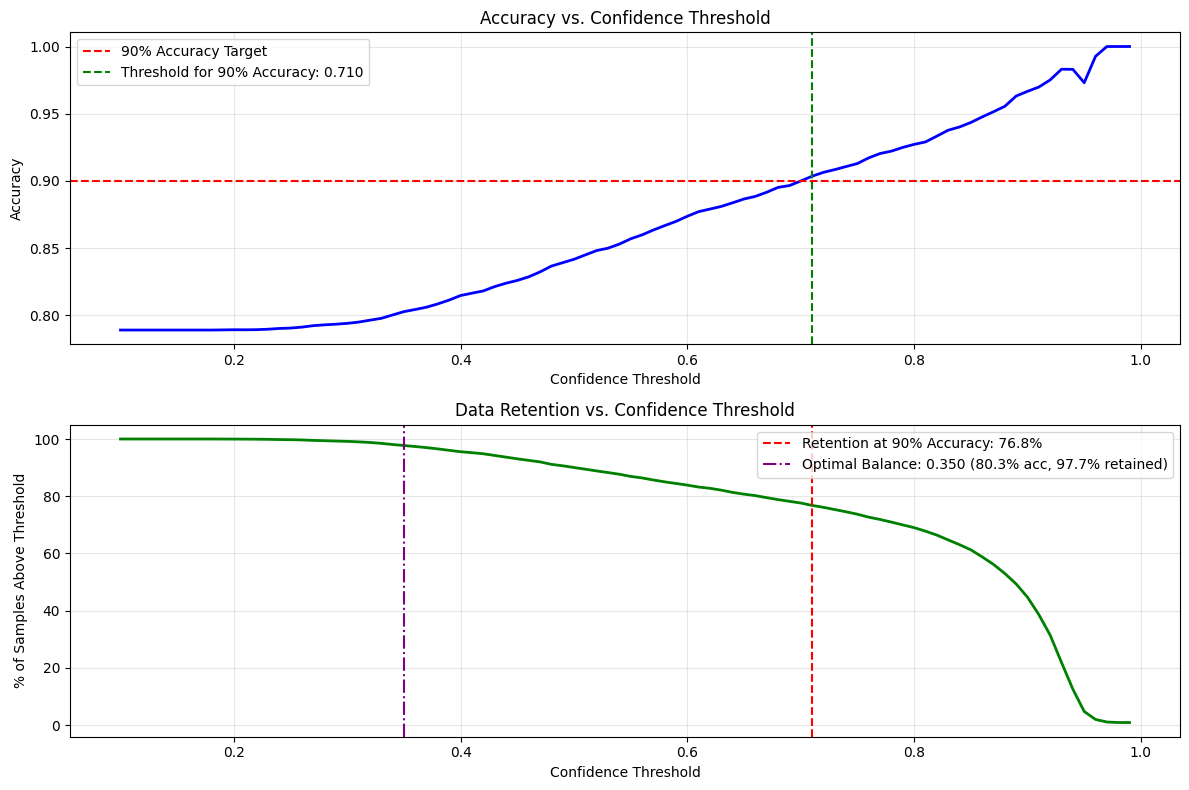


=== CONFIDENCE THRESHOLD RECOMMENDATIONS ===
Threshold for 90% accuracy: 0.710
  - This retains 76.8% of all predictions

Threshold for 90% data retention: 0.510
  - This gives 84.5% accuracy

Optimal threshold balancing accuracy & retention: 0.350
  - Accuracy: 80.3%
  - Retention: 97.7%

Class-specific thresholds for 90% accuracy:
  - ArtocarpusHeterophyllus: 0.210 (retains 77.8% of class samples)
  - BroussonetiaPapyrifera: 0.100 (retains 97.1% of class samples)
  - CeibaPentandra: 0.120 (retains 93.4% of class samples)
  - CocosNucifera: 0.100 (retains 94.9% of class samples)
  - DurioZibethinus: 0.170 (retains 82.0% of class samples)
  - ElaeisGuineensis: 0.100 (retains 97.5% of class samples)
  - EuphorbiaPulcherrima: 0.290 (retains 53.9% of class samples)
  - ManihotEsculenta: 0.100 (retains 95.0% of class samples)
  - SamaneaSaman: 0.180 (retains 68.3% of class samples)
  - TheobromaCacao: 0.120 (retains 88.4% of class samples)


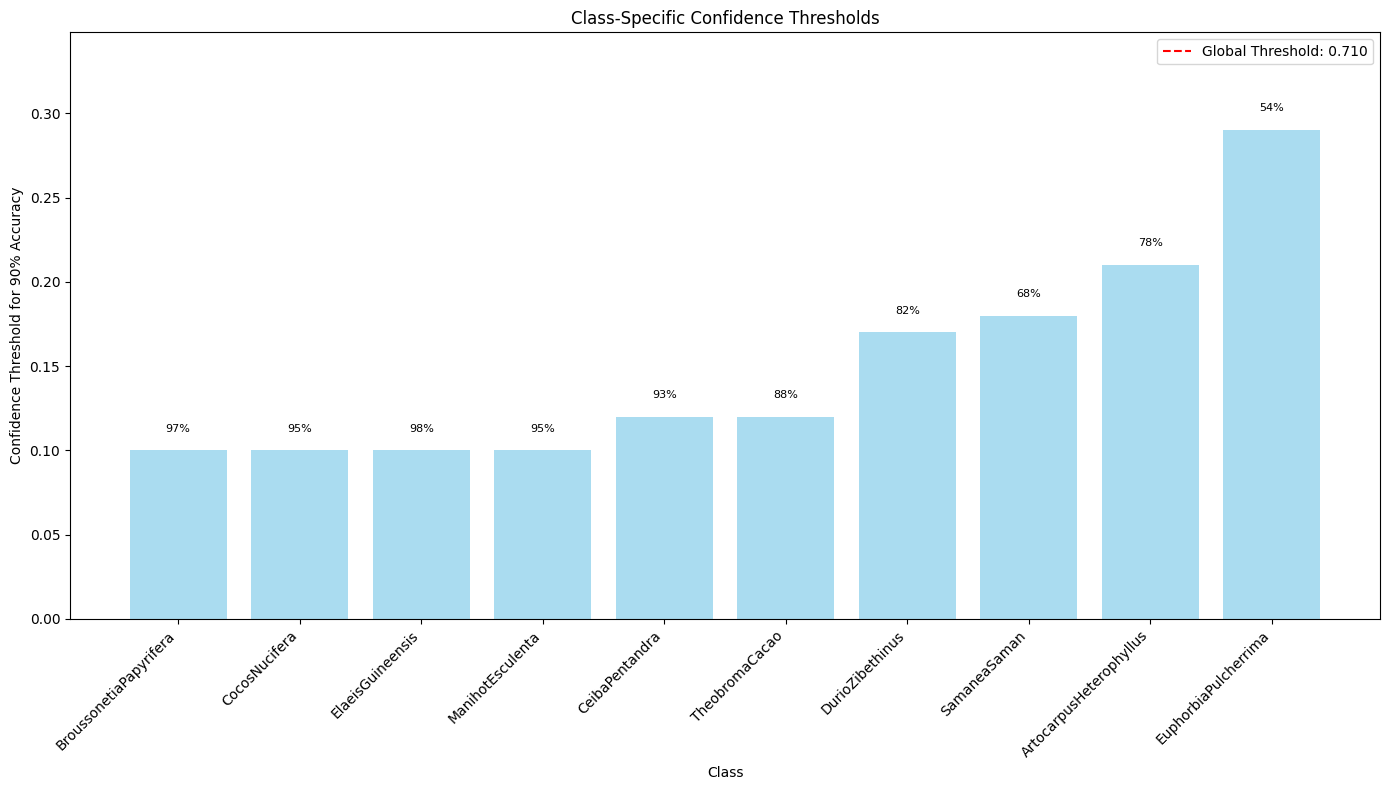


Accuracy for predictions with confidence >= 0.350: 80.27%
Percentage of predictions with high confidence: 97.73%


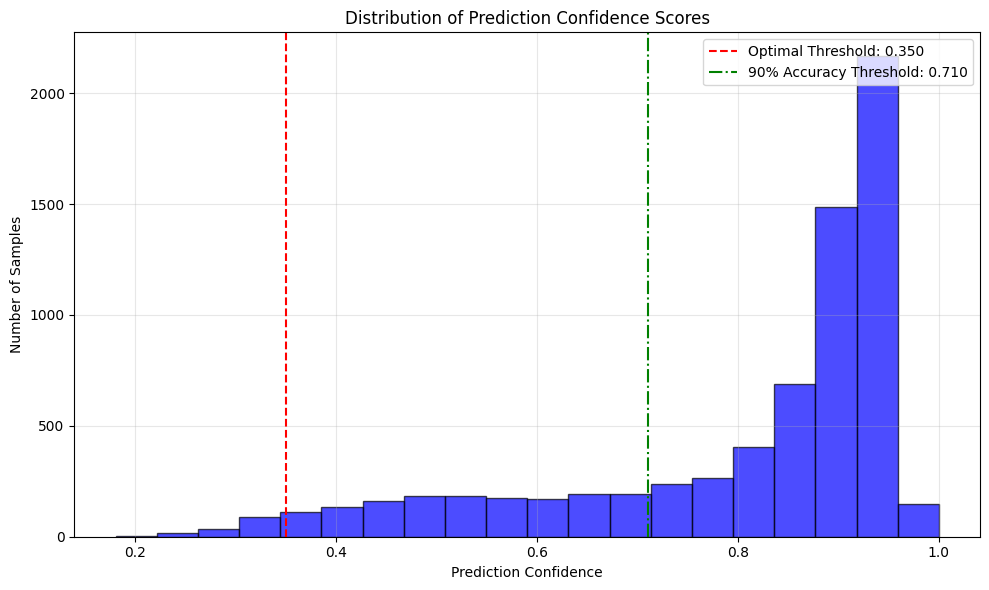


---- Confidence Scoring Guide ----
Confidence Score Range | Interpretation
--------------------------------------------------
0.00 - 0.50 | Low confidence - Requires human verification
0.50 - 0.71 | Medium confidence - Likely correct
0.71 - 1.00 | High confidence - 90%+ accuracy expected

Recommendation: Use this scoring guide in your application UI to communicate prediction confidence to users


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_curve

def analyze_confidence_thresholds(test_labels, test_preds, class_names=None):
    """
    Analyze how prediction accuracy varies with confidence threshold
    
    Args:
        test_labels: Ground truth labels
        test_preds: Model predictions (probabilities)
        class_names: Dictionary mapping class indices to class names
        
    Returns:
        DataFrame with threshold analysis and recommendations
    """
    # Get prediction class and confidence for each sample
    y_pred_class = np.argmax(test_preds, axis=1)
    y_pred_confidence = np.max(test_preds, axis=1)
    
    # Create array indicating if prediction was correct
    correct_predictions = (y_pred_class == test_labels)
    
    # Calculate accuracy at different confidence thresholds
    thresholds = np.linspace(0.1, 0.99, 90)
    threshold_accuracies = []
    samples_above_threshold = []
    
    for threshold in thresholds:
        # Get predictions with confidence above threshold
        above_threshold = y_pred_confidence >= threshold
        
        # Skip if no samples meet this threshold
        if np.sum(above_threshold) == 0:
            threshold_accuracies.append(np.nan)
            samples_above_threshold.append(0)
            continue
            
        # Calculate accuracy for samples above threshold
        accuracy = np.mean(correct_predictions[above_threshold])
        threshold_accuracies.append(accuracy)
        samples_above_threshold.append(np.sum(above_threshold))
    
    # Convert to percentage of total samples
    samples_percentage = [count / len(test_labels) * 100 for count in samples_above_threshold]
    
    # Create results dataframe
    results = pd.DataFrame({
        'Confidence Threshold': thresholds,
        'Accuracy': threshold_accuracies,
        'Samples Above Threshold': samples_above_threshold,
        'Percentage of Dataset': samples_percentage
    })
    
    # Find threshold for 90% accuracy
    accuracy_90_idx = np.argmax(np.array(threshold_accuracies) >= 0.90)
    threshold_90 = results.iloc[accuracy_90_idx]['Confidence Threshold'] if accuracy_90_idx < len(results) else np.nan
    
    # Find threshold where 90% of predictions are retained
    retention_90_idx = np.argmax(np.array(samples_percentage) <= 90.0)
    retention_threshold = results.iloc[retention_90_idx]['Confidence Threshold'] if retention_90_idx < len(results) else np.nan
    
    # Find optimal threshold that balances high accuracy with high retention
    # Using F1-like measure between accuracy and retention rate
    f1_scores = []
    for i in range(len(results)):
        if np.isnan(results.iloc[i]['Accuracy']):
            f1_scores.append(0)
            continue
        
        acc = results.iloc[i]['Accuracy']
        retention = results.iloc[i]['Percentage of Dataset'] / 100
        
        # Only consider thresholds with at least 80% accuracy
        if acc < 0.8:
            f1_scores.append(0)
            continue
            
        f1 = 2 * (acc * retention) / (acc + retention) if (acc + retention) > 0 else 0
        f1_scores.append(f1)
    
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = results.iloc[optimal_idx]['Confidence Threshold']
    optimal_accuracy = results.iloc[optimal_idx]['Accuracy']
    optimal_retention = results.iloc[optimal_idx]['Percentage of Dataset']
    
    # Analyze per-class optimal thresholds for 90% accuracy
    class_thresholds = {}
    if class_names is not None:
        for class_idx in range(len(class_names)):
            # Get samples from this class
            class_mask = (test_labels == class_idx)
            if not any(class_mask):
                continue
                
            class_correct = correct_predictions[class_mask]
            class_confidence = test_preds[class_mask, class_idx]
            
            # Calculate accuracy at different thresholds for this class
            class_accuracies = []
            class_samples = []
            
            for threshold in thresholds:
                above_threshold = class_confidence >= threshold
                if np.sum(above_threshold) == 0:
                    class_accuracies.append(np.nan)
                    class_samples.append(0)
                    continue
                    
                accuracy = np.mean(class_correct[above_threshold])
                class_accuracies.append(accuracy)
                class_samples.append(np.sum(above_threshold))
            
            # Find threshold for 90% accuracy for this class
            try:
                class_acc_90_idx = np.argmax(np.array(class_accuracies) >= 0.90)
                class_threshold = thresholds[class_acc_90_idx] if class_acc_90_idx < len(thresholds) else np.nan
                class_retention = class_samples[class_acc_90_idx] / np.sum(class_mask) * 100 if class_acc_90_idx < len(thresholds) else 0
                
                class_thresholds[class_names[class_idx]] = {
                    '90% Accuracy Threshold': class_threshold,
                    'Retention at Threshold': class_retention
                }
            except:
                class_thresholds[class_names[class_idx]] = {
                    '90% Accuracy Threshold': np.nan,
                    'Retention at Threshold': 0
                }
    
    # Always create visualization
    plt.figure(figsize=(12, 8))
    plt.subplot(2, 1, 1)
    plt.plot(results['Confidence Threshold'], results['Accuracy'], 'b-', linewidth=2)
    plt.axhline(y=0.9, color='r', linestyle='--', label='90% Accuracy Target')
    if not np.isnan(threshold_90):
        plt.axvline(x=threshold_90, color='g', linestyle='--', 
                   label=f'Threshold for 90% Accuracy: {threshold_90:.3f}')
    plt.grid(True, alpha=0.3)
    plt.xlabel('Confidence Threshold')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs. Confidence Threshold')
    plt.legend()
    
    plt.subplot(2, 1, 2)
    plt.plot(results['Confidence Threshold'], results['Percentage of Dataset'], 'g-', linewidth=2)
    if not np.isnan(threshold_90):
        retention_at_90 = results.iloc[accuracy_90_idx]['Percentage of Dataset'] if accuracy_90_idx < len(results) else 0
        plt.axvline(x=threshold_90, color='r', linestyle='--', 
                   label=f'Retention at 90% Accuracy: {retention_at_90:.1f}%')
    plt.axvline(x=optimal_threshold, color='purple', linestyle='-.',
               label=f'Optimal Balance: {optimal_threshold:.3f} ({optimal_accuracy:.1%} acc, {optimal_retention:.1f}% retained)')
    plt.grid(True, alpha=0.3)
    plt.xlabel('Confidence Threshold')
    plt.ylabel('% of Samples Above Threshold')
    plt.title('Data Retention vs. Confidence Threshold')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('confidence_threshold_analysis.png')
    plt.show()  # This will display the plot
    
    # Return results and recommendations
    recommendations = {
        'threshold_90_accuracy': threshold_90,
        'retention_at_90_accuracy': results.iloc[accuracy_90_idx]['Percentage of Dataset'] if accuracy_90_idx < len(results) else 0,
        'threshold_90_retention': retention_threshold,
        'accuracy_at_90_retention': results.iloc[retention_90_idx]['Accuracy'] if retention_90_idx < len(results) else 0,
        'optimal_threshold': optimal_threshold,
        'optimal_accuracy': optimal_accuracy,
        'optimal_retention': optimal_retention,
        'class_thresholds': class_thresholds
    }
    
    return results, recommendations

# To use this function with your existing evaluation:
# results, recommendations = analyze_confidence_thresholds(
#     test_labels, 
#     test_preds,
#     test_dataset.idx_to_class
# )

# Print recommendations
def print_threshold_recommendations(recommendations):
    print("\n=== CONFIDENCE THRESHOLD RECOMMENDATIONS ===")
    print(f"Threshold for 90% accuracy: {recommendations['threshold_90_accuracy']:.3f}")
    print(f"  - This retains {recommendations['retention_at_90_accuracy']:.1f}% of all predictions")
    print(f"\nThreshold for 90% data retention: {recommendations['threshold_90_retention']:.3f}")
    print(f"  - This gives {recommendations['accuracy_at_90_retention']:.1%} accuracy")
    print(f"\nOptimal threshold balancing accuracy & retention: {recommendations['optimal_threshold']:.3f}")
    print(f"  - Accuracy: {recommendations['optimal_accuracy']:.1%}")
    print(f"  - Retention: {recommendations['optimal_retention']:.1f}%")
    
    print("\nClass-specific thresholds for 90% accuracy:")
    for class_name, values in recommendations['class_thresholds'].items():
        threshold = values['90% Accuracy Threshold']
        retention = values['Retention at Threshold']
        if np.isnan(threshold):
            print(f"  - {class_name}: Unable to achieve 90% accuracy with any threshold")
        else:
            print(f"  - {class_name}: {threshold:.3f} (retains {retention:.1f}% of class samples)")

# ------------------- Complete Code to Add to Your Script -------------------
# Add these lines after you've evaluated your model:

# This is ready-to-use code (no need for comments)
def visualize_class_thresholds(recommendations, test_dataset):
    """Create a visualization of class-specific thresholds"""
    class_thresholds = recommendations['class_thresholds']
    
    # Extract class names and thresholds
    classes = []
    thresholds = []
    retention_rates = []
    
    for class_name, values in class_thresholds.items():
        threshold = values['90% Accuracy Threshold']
        retention = values['Retention at Threshold']
        
        # Skip if threshold couldn't be determined
        if np.isnan(threshold):
            continue
            
        classes.append(class_name)
        thresholds.append(threshold)
        retention_rates.append(retention)
    
    # Sort by threshold value
    sorted_indices = np.argsort(thresholds)
    classes = [classes[i] for i in sorted_indices]
    thresholds = [thresholds[i] for i in sorted_indices]
    retention_rates = [retention_rates[i] for i in sorted_indices]
    
    # Create visualization
    plt.figure(figsize=(14, 8))
    
    # Bar plot for thresholds
    ax1 = plt.subplot(1, 1, 1)
    bars = ax1.bar(classes, thresholds, color='skyblue', alpha=0.7)
    ax1.set_xlabel('Class')
    ax1.set_ylabel('Confidence Threshold for 90% Accuracy')
    ax1.set_title('Class-Specific Confidence Thresholds')
    ax1.axhline(y=recommendations['threshold_90_accuracy'], color='r', linestyle='--', 
                label=f'Global Threshold: {recommendations["threshold_90_accuracy"]:.3f}')
    
    # Add retention rate as text on bars
    for i, (bar, retention) in enumerate(zip(bars, retention_rates)):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{retention:.0f}%', ha='center', va='bottom', rotation=0, fontsize=8)
    
    ax1.set_ylim(0, min(1.0, max(thresholds) * 1.2))  # Set y-limit with some margin
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.savefig('class_specific_thresholds.png')
    plt.show()

# Add this to your main code after model evaluation
print("\n---- Confidence Threshold Analysis ----")
results, recommendations = analyze_confidence_thresholds(
    test_labels, 
    test_preds,
    test_dataset.idx_to_class
)
print_threshold_recommendations(recommendations)

# Visualize class-specific thresholds
visualize_class_thresholds(recommendations, test_dataset)

# Find which samples exceed the optimal threshold and are correct
y_pred_class = np.argmax(test_preds, axis=1)
y_pred_confidence = np.max(test_preds, axis=1)
optimal_threshold = recommendations['optimal_threshold']

high_confidence_mask = y_pred_confidence >= optimal_threshold
correct_predictions = (y_pred_class == test_labels)
high_confidence_correct = correct_predictions & high_confidence_mask

# Calculate high confidence accuracy
high_confidence_accuracy = np.sum(high_confidence_correct) / np.sum(high_confidence_mask) if np.sum(high_confidence_mask) > 0 else 0
print(f"\nAccuracy for predictions with confidence >= {optimal_threshold:.3f}: {high_confidence_accuracy:.2%}")
print(f"Percentage of predictions with high confidence: {np.mean(high_confidence_mask):.2%}")

# Create a second visualization showing confidence distribution
plt.figure(figsize=(10, 6))
plt.hist(y_pred_confidence, bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(x=optimal_threshold, color='red', linestyle='--', 
           label=f'Optimal Threshold: {optimal_threshold:.3f}')
plt.axvline(x=recommendations['threshold_90_accuracy'], color='green', linestyle='-.',
           label=f'90% Accuracy Threshold: {recommendations["threshold_90_accuracy"]:.3f}')
plt.xlabel('Prediction Confidence')
plt.ylabel('Number of Samples')
plt.title('Distribution of Prediction Confidence Scores')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('confidence_distribution.png')
plt.show()

# Generate an example confidence scoring guide
confidence_ranges = [
    (0.0, 0.5, "Low confidence - Requires human verification"),
    (0.5, recommendations['threshold_90_accuracy'], "Medium confidence - Likely correct"),
    (recommendations['threshold_90_accuracy'], 1.0, "High confidence - 90%+ accuracy expected")
]

print("\n---- Confidence Scoring Guide ----")
print("Confidence Score Range | Interpretation")
print("-" * 50)
for low, high, interpretation in confidence_ranges:
    print(f"{low:.2f} - {high:.2f} | {interpretation}")
print("\nRecommendation: Use this scoring guide in your application UI to communicate prediction confidence to users")